# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 3     |  |
| :-------------|:-------------|
| Tim Mekkelholt| 6224687 |
| Raphaelle Tam| 6504272 |
| Emma van der Grinten| 6404618 |
| Planning Groep: 3     |Tijdstip / Tijdspanne  |
|---|---|
| Oscilloscoop testen (check 1) | 10:45-11:15 |
| Condensator testen (check 2) | 11:15-11:45 |
| Condensator ontwerpen en bouwen (check 3) | 11:45-12:30 |
| Pauze 1 | 12:30-13:30 |
| Sensor ontwerpen | 13:30-14:30 |
| Opstelling bouwen + eerste meting | 14:30-15:00 |
| Resterende metingen met arduino | 15:00-15:30 |
| data analyse en eventuele iteraties | 15:30-16:30 |
| Afronden + feedback geven | 16:30-17:30 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
 ![Schematische tekening](SchemaCondensator.png)

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
epsillon0 = 8.854187817e-12  # F/m

def vlakkeplaat(epsillonr,A,d):
    C = epsillon0 * epsillonr * A / d      
    return C # F

print(f"de condensator heeft een capaciteit van C = {vlakkeplaat(2.5, 0.01, 0.002):.2e} F")
# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

de condensator heeft een capaciteit van C = 1.11e-10 F


In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = [vlakkeplaat(2.5, 0.01, 0.00017), vlakkeplaat(2.5, 0.01, 0.002)]

print(f"Berekende capaciteit plaatcondensator groep 3 is {C[0]*1e12:.1f} pF")
print(f"Berekende capaciteit plaatcondensator groep 3 is {C[1]*1e12:.1f} pF")



Berekende capaciteit plaatcondensator groep 3 is 1302.1 pF
Berekende capaciteit plaatcondensator groep 3 is 110.7 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![Schematische tekening](Opdracht2opstelling.jpg)
![Schem](Opdracht2opstelling2.jpg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit (pF)  | Berekend Voltage (V)| Gemeten Voltage (V) | Gemeten capaciteit (pF) |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 3| 110.7  | 0.553 | 0.494 | 98.2 |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](schets.jpg)
![](Schets2.png)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die massa meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](schetsfinal.png)

De fit parameters zijn: a = 80.0 pF/kg, b = -18.1 pF


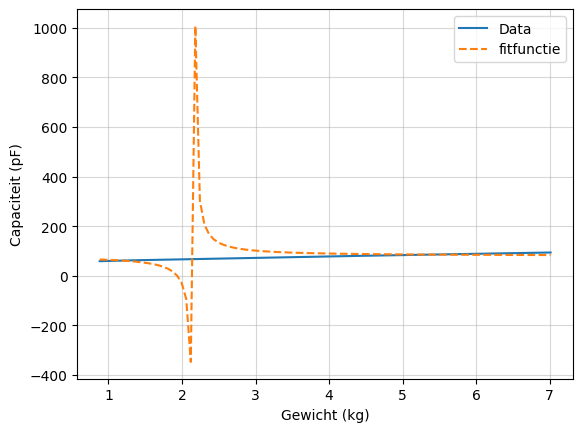

In [3]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gewichten_test = np.array([0.881,1.310 ,4.457, 7.013 ])
capaciteiten_test = np.array([59.0, 62.4 ,80.7, 94.0]) 

def testfunc(x, a, b, c):
    return a + b/(c-x) #past niet goed maar wel fyscisch correct.

vals, covs = curve_fit(testfunc, gewichten_test, capaciteiten_test)
x_fit = np.linspace(min(gewichten_test), max(gewichten_test), 100)

plt.figure()
plt.plot(gewichten_test, capaciteiten_test, '-', label='Data')
plt.plot(x_fit, testfunc(x_fit, *vals), '--', label='fitfunctie')
plt.xlabel('Gewicht (kg)')
plt.ylabel('Capaciteit (pF)')
plt.grid(alpha=0.5)
plt.legend()

print(f"De fit parameters zijn: a = {vals[0]:.1f} pF/kg, b = {vals[1]:.1f} pF")

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 12 | 60 |
| gemiddelde capaciteit| 35 | 175 |
| maximale capaciteit| 61 | 300 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![Uiteindelijke meetopstelling met arduino](opstellingarduino.png)
![Testopstelling met oscilloscoop](opstellingfinal.jpg)

## Opdracht 7: Plot de kalibratiegrafiek.

[ 79.96733876 -18.1163752    2.16219754]


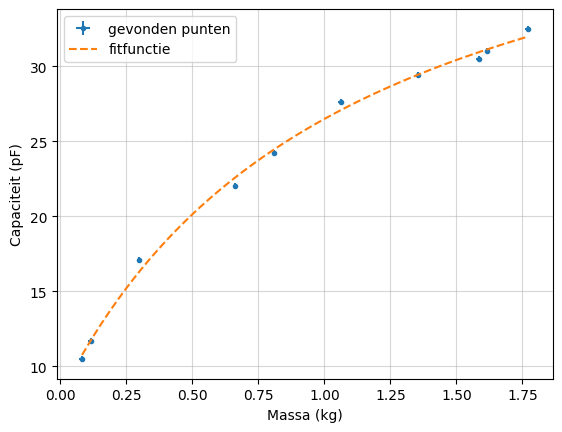

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
gewichten = np.array([0.082, 0.115, 0.299, 0.662, 0.810, 1.061, 1.356, 1.585, 1.617, 1.770])
u_gewichten = 0.01
capaciteiten = np.array([10.5, 11.7, 17.1, 22.0, 24.2, 27.6, 29.4, 30.5, 31.0, 32.5])
u_capaciteiten = 0.2

def testfit(x, a, b, c):
    return c + a/(b+x) 
#functie heeft een verwachtte vorm van c+a/(b-x), maar deze gaf geen passende fit. verklaring in conclusie.

vals1, covs1 = curve_fit(testfit, gewichten, capaciteiten)
x_fit = np.linspace(min(gewichten), max(gewichten), 100)
print(vals)

plt.Figure()
plt.errorbar(gewichten, capaciteiten, xerr=u_gewichten, yerr=u_capaciteiten, label = 'gevonden punten', fmt='.')
plt.errorbar(x_fit, testfit(x_fit, *vals1), label = 'fitfunctie', fmt='--')
plt.grid(alpha=0.5)
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.legend()
plt.show()


## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* Een stabielere sensor door bijvoorbeeld een omhulzing voor de condensatorplaten.
* Echte veren gebruiken als tussenstuk in plaats van een spons. De geleiding van de spons verandert met de indrukking door de hoeveelheid lucht in de spons.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](opstellingarduino.png)

## Opdracht 10: Vul hieronder de conclusie in.

Volgens de theorie voor een plaatcondensator geldt: $C = \varepsilon*A/d$. Waardoor de capaciteit toeneemt als de plaatafstand kleiner wordt. In onze metingen stijgt de capaciteit ook met toenemend gewicht, maar het verband vlakt af en wijkt daarmee af van het ideale (lineaire indrukking) model, waarschijnlijk door de niet-lineaire veerwerking van de spons en/of een minimale plaatafstand. De sensor werkt dus als gewichtsensor, maar vereist een niet-lineaire kalibratie en tests op reproduceerbaarheid voordat hij geschikt is als betrouwbare weegschaal.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
epsillon0 = 8.854187817e-12  # F/m

def vlakkeplaat(epsillonr,A,d):
    C = epsillon0 * epsillonr * A / d      
    return C # F

print(f"de condensator heeft een capaciteit van C = {vlakkeplaat(2.5, 0.01, 0.002):.2e} F")

# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gewichten_test = np.array([0.881,1.310 ,4.457, 7.013 ])
capaciteiten_test = np.array([59.0, 62.4 ,80.7, 94.0]) 

def testfunc(x, a, b, c):
    return a + b/(c-x) #past niet goed maar wel fyscisch correct.

vals, covs = curve_fit(testfunc, gewichten_test, capaciteiten_test)
x_fit = np.linspace(min(gewichten_test), max(gewichten_test), 100)

plt.figure()
plt.plot(gewichten_test, capaciteiten_test, '-', label='Data')
plt.plot(x_fit, testfunc(x_fit, *vals), '--', label='fitfunctie')
plt.xlabel('Gewicht (kg)')
plt.ylabel('Capaciteit (pF)')
plt.grid(alpha=0.5)
plt.legend()

print(f"De fit parameters zijn: a = {vals[0]:.1f} pF/kg, b = {vals[1]:.1f} pF")

 ![kalibratiegrafiek](verwachting.png)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.
#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![Schematische tekening](Opdracht2opstelling.jpg)
![Schem](Opdracht2opstelling2.jpg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.
gewichten = np.array([0.082, 0.115, 0.299, 0.662, 0.810, 1.061, 1.356, 1.585, 1.617, 1.770])
u_gewichten = 0.01
capaciteiten = np.array([10.5, 11.7, 17.1, 22.0, 24.2, 27.6, 29.4, 30.5, 31.0, 32.5])
u_capaciteiten = 0.2

def testfit(x, a, b, c):
    return c + a/(b+x) 
#functie heeft een verwachtte vorm van c+a/(b-x), maar deze gaf geen passende fit. verklaring in conclusie.

vals1, covs1 = curve_fit(testfit, gewichten, capaciteiten)
x_fit = np.linspace(min(gewichten), max(gewichten), 100)
print(vals)

plt.Figure()
plt.errorbar(gewichten, capaciteiten, xerr=u_gewichten, yerr=u_capaciteiten, label = 'gevonden punten', fmt='.')
plt.errorbar(x_fit, testfit(x_fit, *vals1), label = 'fitfunctie', fmt='--')
plt.grid(alpha=0.5)
plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (pF)')
plt.legend()
plt.show()

![](final.png)

Volgens de theorie voor een plaatcondensator geldt: $C = \varepsilon*A/d$. Waardoor de capaciteit toeneemt als de plaatafstand kleiner wordt. In onze metingen stijgt de capaciteit ook met toenemend gewicht, maar het verband vlakt af en wijkt daarmee af van het ideale (lineaire indrukking) model, waarschijnlijk door de niet-lineaire veerwerking van de spons en/of een minimale plaatafstand. De sensor werkt dus als gewichtsensor, maar vereist een niet-lineaire kalibratie en tests op reproduceerbaarheid voordat hij geschikt is als betrouwbare weegschaal.